# Проект
Представьте, что вы работаете в крупном дейтинговом приложении.
  
Помимо базовых функций, в приложении также имеется премиум-подписка, которая дает доступ к ряду важных дополнительных возможностей. Был проведен A/B тест, в рамках которого для новых пользователей из нескольких стран была изменена стоимость премиум-подписки* при покупке через две новые платежные системы. При этом стоимость пробного периода оставалась прежней.  

Проверьте:

1. Был ли эксперимент успешен в целом.  
*Деньги за подписку списываются ежемесячно до тех пор, пока пользователь её не отменит.

**Важно**: это задание наиболее приближено к работе с реальными данными, и в реальных данных часто бывают ошибки и подвохи. Будьте аккуратны и не торопитесь при анализе — уделите как можно больше внимания этим данным.

## Данные
Всего есть три группы: тестовая (test), контрольная 1 (control_1) и контрольная 2 (control_2). Для каждой из них:

**users_*.csv** – информация о пользователях:

- **uid** – идентификатор пользователя  
- **age** – возраст  
- **attraction_coeff** – коэффициент привлекательности (от 0 до 1000, лайки / просмотры ∗1000)
- **coins** – число монеток (внутренняя валюта)  
- **country** – страна  
- **visit_days** – в какие дни после регистрации пользователь посещал приложение (напр. в 1, затем в 7)
- **gender** – пол
- **age_filter_start**  – фильтр поиска, мин. значение 
- **age_filter_end**  – фильтр поиска, макс. значение 
- **views_count** – число полученных оценок 
- **was_premium** – был ли когда-либо премиум (либо пробный период премиум-статуса, либо купленный за деньги)
- **is_premium** –  является ли премиум
- **total_revenue** – нормированная выручка 

**transactions_*.csv** – информация о платежах пользователей:

- **uid** – идентификатор пользователя
- **country** – страна
- **joined_at** – дата и время регистрации
- **paid_at** – дата и время покупки
- **revenue** – нормированная выручка
- **payment_id** – идентификатор платежа
- **from_page** – откуда пользователь перешел на страницу оплаты
- **product_type** – тип продукта (trial_premium – пробная премиум-подписка, premium_no_trial – премиум-подписка без пробной, coins – подписка за внутреннюю валюту, other_type – другое) 

In [268]:
#Импорт необходимых бибилиотек
import numpy as np
import pandas as pd

import scipy.stats as ss
import pingouin as pg
import statsmodels.api as sm

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(rc={'figure.figsize': (12, 6)}, style='white')

## 1. Считывание и фильтрация данных. 

In [269]:
users_test = pd.read_csv('~/Проект_3_users_test.csv', sep=';')
users_control_1 = pd.read_csv('~/Проект_3_users_control_1.csv', sep=';')
users_control_2 = pd.read_csv('~/Проект_3_users_control_2.csv', sep=';')

transactions_test = pd.read_csv('~/Проект_3_transactions_test.csv', sep=';')
transactions_control_1 = pd.read_csv('~/Проект_3_transactions_control_1.csv', sep=';')
transactions_control_2 = pd.read_csv('~/Проект_3_transactions_control_2.csv', sep=';')

### Пройдёмся по информации о пользователях.

In [270]:
users_test.head()

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
0,892309896,27,685,NaN,United States of America,"1,2,3,4,5,6,7,8,9,10,11,12,16,17",1,24,30,89,NaN,NaN,0
1,892044516,27,0,NaN,Germany,NaN,1,24,30,0,NaN,NaN,0
2,892185708,45,44,NaN,Israel,"1,3,4,6,7,8,10,11,12,13,14,15,16,17,18,19,20,2...",1,42,48,68,NaN,NaN,0
3,892130292,32,0,NaN,United States of America,"1,2,3,4,5,6,7,8,9,10,11,12",1,29,35,0,NaN,NaN,0
4,891406035,27,1000,NaN,France,NaN,1,24,30,1,1.0,NaN,0


In [271]:
users_control_1.head()

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
0,892319115,25,435,NaN,United States of America,"1,2,3,4,5,6",0,22,32,982,NaN,NaN,0
1,891248523,29,500,NaN,United States of America,"1,2",1,26,32,12,NaN,NaN,0
2,891670932,33,800,NaN,France,"1,2,3,5,6,8,9,11,13,16",1,30,36,5,NaN,NaN,0
3,891060786,26,0,NaN,Argentina,"1,2,3,4,5",1,23,29,0,NaN,NaN,0
4,892006554,35,294,NaN,United States of America,"1,2,3,5,6,7,8,9,10,12,15,16,17,19",1,30,40,17,NaN,NaN,0


In [272]:
users_control_2.head()

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
0,892035504,37,137,NaN,Israel,"1,2,3,4,5,6,7,8,9,11,13",1,30,40,51,NaN,NaN,0
1,891782112,57,0,NaN,Italy,1,1,54,60,0,NaN,NaN,0
2,891110337,30,769,NaN,France,"1,2,3,4,5",1,27,33,13,NaN,NaN,0
3,891796320,48,750,NaN,France,"1,4,6,8,10,11,12,14,15,16,18",1,45,51,12,NaN,NaN,0
4,891880212,54,638,NaN,United States of America,1,1,35,53,94,NaN,NaN,0


In [273]:
#Кол-во строк и столбцов в датафреймах
print(users_test.shape)
print(users_control_1.shape)
print(users_control_2.shape)

(4308, 13)
(4340, 13)
(4264, 13)


In [274]:
#Наличие дубликатов
print(users_test.duplicated().sum())
print(users_control_1.duplicated().sum())
print(users_control_2.duplicated().sum())

0
0
0


Дубликатов нет.

In [275]:
users_test.isna().sum()

uid                    0
age                    0
attraction_coeff       0
coins               4259
country                0
visit_days          1330
gender                 0
age_filter_start       0
age_filter_end         0
views_count            0
was_premium         3900
is_premium          4151
total_revenue          0
dtype: int64

In [276]:
users_control_1.isna().sum()

uid                    0
age                    0
attraction_coeff       0
coins               4280
country                0
visit_days          1324
gender                 0
age_filter_start       0
age_filter_end         0
views_count            0
was_premium         3904
is_premium          4148
total_revenue          0
dtype: int64

In [277]:
users_control_2.isna().sum()

uid                    0
age                    0
attraction_coeff       0
coins               4203
country                0
visit_days          1364
gender                 0
age_filter_start       0
age_filter_end         0
views_count            0
was_premium         3853
is_premium          4073
total_revenue          0
dtype: int64

In [278]:
users_test.was_premium.unique()

array([nan,  1.])

In [279]:
users_test.is_premium.unique()

array([nan,  1.])

Что касается пропущенных значений - нет данных о кол-ве внутриигровой валюты и в какие дни после регистрации пользователь посещал приложение. Для анализа это не критично.  
Информация о статусе "премиум", вероятно, должна иметь дихотомическую кодировку, где 0 - "нет", 1 - "да". Для удобства вместо пустых значений проставим 0. 

In [280]:
users_test = users_test.fillna(0)
users_control_1 = users_control_1.fillna(0)
users_control_2 = users_control_2.fillna(0)

Теперь посмотрим на итоговую информацию после предобработки и удостоверимся в корректности типов данных. А также проверим, есть ли повторяющиеся пользователи как внутри каждого датафрейма, так и между ними, чтобы далее объединить данные вместе.

In [281]:
users_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4308 entries, 0 to 4307
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uid               4308 non-null   int64  
 1   age               4308 non-null   int64  
 2   attraction_coeff  4308 non-null   int64  
 3   coins             4308 non-null   float64
 4   country           4308 non-null   object 
 5   visit_days        4308 non-null   object 
 6   gender            4308 non-null   int64  
 7   age_filter_start  4308 non-null   int64  
 8   age_filter_end    4308 non-null   int64  
 9   views_count       4308 non-null   int64  
 10  was_premium       4308 non-null   float64
 11  is_premium        4308 non-null   float64
 12  total_revenue     4308 non-null   int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 437.7+ KB


In [282]:
users_test.uid.nunique()

4308

In [283]:
users_control_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uid               4340 non-null   int64  
 1   age               4340 non-null   int64  
 2   attraction_coeff  4340 non-null   int64  
 3   coins             4340 non-null   float64
 4   country           4340 non-null   object 
 5   visit_days        4340 non-null   object 
 6   gender            4340 non-null   int64  
 7   age_filter_start  4340 non-null   int64  
 8   age_filter_end    4340 non-null   int64  
 9   views_count       4340 non-null   int64  
 10  was_premium       4340 non-null   float64
 11  is_premium        4340 non-null   float64
 12  total_revenue     4340 non-null   int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 440.9+ KB


In [284]:
users_control_1.uid.nunique()

4340

In [285]:
users_control_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4264 entries, 0 to 4263
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uid               4264 non-null   int64  
 1   age               4264 non-null   int64  
 2   attraction_coeff  4264 non-null   int64  
 3   coins             4264 non-null   float64
 4   country           4264 non-null   object 
 5   visit_days        4264 non-null   object 
 6   gender            4264 non-null   int64  
 7   age_filter_start  4264 non-null   int64  
 8   age_filter_end    4264 non-null   int64  
 9   views_count       4264 non-null   int64  
 10  was_premium       4264 non-null   float64
 11  is_premium        4264 non-null   float64
 12  total_revenue     4264 non-null   int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 433.2+ KB


In [286]:
users_control_2.uid.nunique()

4264

Проверим, есть ли пересчения в uid.

In [287]:
set1 = set(users_test['uid'])
set2 = set(users_control_1['uid'])
set3 = set(users_control_2['uid'])

In [288]:
common1 = set1.intersection(set2)
common2 = set1.intersection(set3)
common3 = set2.intersection(set3)
print(common1)
print(common2)
print(common3)

set()
set()
set()


Повторяющихся uid нет, поэтому можем объединить наши датафреймы в один, предварительно добавив колонку с информацией о принадлежности к группе.

In [289]:
users_test['group'] = 'test'
users_control_1['group'] = 'control_1'
users_control_2['group'] = 'control_2'

users_df = pd.concat([users_test, users_control_1, users_control_2], ignore_index=True)

In [290]:
users_df.shape

(12912, 14)

In [291]:
users_df.dtypes

uid                   int64
age                   int64
attraction_coeff      int64
coins               float64
country              object
visit_days           object
gender                int64
age_filter_start      int64
age_filter_end        int64
views_count           int64
was_premium         float64
is_premium          float64
total_revenue         int64
group                object
dtype: object

In [292]:
users_df.uid.nunique()

12912

### Теперь пройдёмся по информации о транзакциях.

In [293]:
transactions_test.head()

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891345942,Italy,2017-05-11 13:00:00,2017-11-13 15:04:00,12909,147,trial_vip_popup,trial_premium
1,892054251,United States of America,2017-10-22 00:33:00,2017-10-30 01:37:00,13923,147,trial_vip_popup,trial_premium
2,892236423,United States of America,2017-10-18 01:09:00,2017-10-23 00:15:00,3783,67,menu,other_type
3,892236423,United States of America,2017-10-18 01:09:00,2017-10-27 22:38:00,3783,67,menu,other_type
4,892168170,United States of America,2017-10-19 17:10:00,2017-10-27 19:10:00,9087,147,trial_vip_popup,trial_premium


In [294]:
transactions_control_1.head()

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891319275.0,France,2017-05-11 19:57:00,2017-12-11 21:57:00,12727.0,147.0,trial_vip_popup,trial_premium
1,892421826.0,Israel,2017-10-14 12:46:00,2017-10-23 12:54:00,14586.0,147.0,trial_vip_popup,trial_premium
2,891822480.0,Italy,2017-10-26 22:27:00,2017-12-11 20:59:00,1911.0,19.0,none,coins
3,891367521.0,Italy,2017-05-11 02:37:00,2017-06-11 19:15:00,1456.0,127.0,sympathy,other_type
4,892207959.0,France,2017-10-18 18:30:00,2017-12-11 12:03:00,1261.0,19.0,empty_likes,coins


In [295]:
transactions_control_2.head()

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891266616,Argentina,2017-06-11 15:25:00,2017-10-11 17:35:00,6305,19,autorefill,coins
1,892186737,Chile,2017-10-19 06:03:00,2017-04-11 08:53:00,4732,147,promo_09,premium_no_trial
2,891959004,United States of America,2017-10-24 00:12:00,2017-10-31 02:12:00,10153,147,trial_vip_popup,trial_premium
3,892115478,Spain,2017-10-20 20:39:00,2017-10-26 06:26:00,2366,67,empty_likes,other_type
4,891592941,Switzerland,2017-10-31 12:40:00,2017-03-11 16:25:00,6292,147,promo_09,premium_no_trial


В колонке uid видим разные типы данных. Проверим, как их считывает пандас и приведём к одному типу. Но сначала удалим дубликаты, чтобы преобразование не привело к ошибке.  
*Что касается датафрейма о транзакцияъ, здесь нет необходимости удалять строки с повторяющимися пользователями, так как они могут проводить платежи многократно, и каждая строка - это уникальная транзакция.*

In [296]:
#Кол-во строк и столбцов в датафреймах
print(transactions_test.shape)
print(transactions_control_1.shape)
print(transactions_control_2.shape)

(273, 8)
(1007, 8)
(328, 8)


In [297]:
#Наличие дубликатов
print(transactions_test.duplicated().sum())
print(transactions_control_1.duplicated().sum())
print(transactions_control_2.duplicated().sum())

7
650
5


In [298]:
#Удаляем дубликаты
transactions_test = transactions_test.drop_duplicates()
transactions_control_1 = transactions_control_1.drop_duplicates()
transactions_control_2 = transactions_control_2.drop_duplicates()

In [299]:
print(transactions_test.shape)
print(transactions_control_1.shape)
print(transactions_control_2.shape)

(266, 8)
(357, 8)
(323, 8)


Проверяем пропуски.

In [300]:
transactions_test.isna().sum()

uid             0
country         0
joined_at       0
paid_at         0
revenue         0
payment_id      0
from_page       0
product_type    0
dtype: int64

In [301]:
transactions_control_1.isna().sum()

uid             1
country         1
joined_at       0
paid_at         0
revenue         1
payment_id      1
from_page       1
product_type    1
dtype: int64

In [302]:
transactions_control_2.isna().sum()

uid             0
country         0
joined_at       0
paid_at         0
revenue         0
payment_id      0
from_page       0
product_type    0
dtype: int64

В контрольной группе 1 есть один пропуск. Найдём и удалим его.

In [303]:
transactions_control_1[transactions_control_1.isna().any(axis=1)]

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
377,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN


In [304]:
transactions_control_1 = transactions_control_1.drop(377)

In [305]:
transactions_control_1.isna().sum()

uid             0
country         0
joined_at       0
paid_at         0
revenue         0
payment_id      0
from_page       0
product_type    0
dtype: int64

In [306]:
print(transactions_control_1.shape)

(356, 8)


Меняем тип данных.

In [307]:
transactions_test.uid.dtypes

dtype('int64')

In [308]:
transactions_control_1.uid.dtypes

dtype('float64')

In [309]:
transactions_control_2.uid.dtypes

dtype('int64')

In [310]:
transactions_control_1['uid'] = transactions_control_1['uid'].astype('int64')

Наконец, можем объединить наши датафреймы в один, предварительно добавив колонку с информацией о принадлежности к группе.

In [311]:
transactions_test.dtypes

uid              int64
country         object
joined_at       object
paid_at         object
revenue          int64
payment_id       int64
from_page       object
product_type    object
dtype: object

In [312]:
transactions_control_1.dtypes

uid               int64
country          object
joined_at        object
paid_at          object
revenue         float64
payment_id      float64
from_page        object
product_type     object
dtype: object

In [313]:
transactions_control_2.dtypes

uid              int64
country         object
joined_at       object
paid_at         object
revenue          int64
payment_id       int64
from_page       object
product_type    object
dtype: object

In [314]:
transactions_test['group'] = 'test'
transactions_control_1['group'] = 'control_1'
transactions_control_2['group'] = 'control_2'

transactions_df = pd.concat([transactions_test, transactions_control_1, transactions_control_2], ignore_index=True)

In [315]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 945 entries, 0 to 944
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   uid           945 non-null    int64  
 1   country       945 non-null    object 
 2   joined_at     945 non-null    object 
 3   paid_at       945 non-null    object 
 4   revenue       945 non-null    float64
 5   payment_id    945 non-null    float64
 6   from_page     945 non-null    object 
 7   product_type  945 non-null    object 
 8   group         945 non-null    object 
dtypes: float64(2), int64(1), object(6)
memory usage: 66.6+ KB


Итого составлены 2 датафрейма:  
- **users_df** - информация о всех пользователях;
- **transactions_df** - информация о платежах всех пользователей.

In [316]:
users_df.shape

(12912, 14)

In [317]:
transactions_df.shape

(945, 9)

In [318]:
#Кол-во уникальных пользователей в users_df
users_df.uid.nunique()

12912

In [319]:
#Кол-во уникальных пользователей в transactions_df
transactions_df.uid.nunique()

526

### Далее необходимо отобрать наблюдения таким образом, чтобы в контрольных и тестовой группах мы исследовали один и тот же пласт пользователей:  
- одинаковая дата регистрации новых пользователей
- страна пользователя
- при оплате использовались две новые платежные системы
- покупалась премиум-подписка

Для этого сначала посмотрим, какие пользователи отнесены к тестовой группе.  
Начнём с даты, изменим тип данных. В целом, информация о времени нам не нужна, поэтому трансформируем дату так, чтобы остались только год, месяц и день.

In [320]:
transactions_df['joined_at'] = pd.to_datetime(transactions_df['joined_at']).dt.normalize()
transactions_df['paid_at'] = pd.to_datetime(transactions_df['paid_at']).dt.normalize()

In [321]:
#Период регистрации пользователей в тестовой группе
print(transactions_df.query('group == "test"').joined_at.min(), 
      transactions_df.query('group == "test"').joined_at.max())

2017-01-11 00:00:00 2017-10-31 00:00:00


In [322]:
#Период регистрации пользователей в 1 контрольной группе
print(transactions_df.query('group == "control_1"').joined_at.min(), 
      transactions_df.query('group == "control_1"').joined_at.max())

2015-01-19 00:00:00 2017-10-31 00:00:00


In [323]:
#Период регистрации пользователей во 2 контрольной группе
print(transactions_df.query('group == "control_2"').joined_at.min(), 
      transactions_df.query('group == "control_2"').joined_at.max())

2017-01-11 00:00:00 2017-10-31 00:00:00


В данных оказались записи за 2015 год. Найдём этих пользователей и удалим из обоих датафреймов.

In [324]:
transactions_df.query('joined_at < "2017-01-11"')

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type,group
330,960936960,Russian Federation,2015-01-19,2016-12-14,26.0,0.0,refund_VP,other_type,control_1
364,960936960,Russian Federation,2015-01-19,2016-12-14,637.0,0.0,refung_AP,other_type,control_1
481,960936960,Russian Federation,2015-01-19,2016-12-14,143.0,0.0,refund_WP,other_type,control_1


In [325]:
transactions_df = transactions_df.query("uid != 960936960")
users_df = users_df.query("uid != 960936960")

Теперь отберём страны. Нам нужно оставить только те, которые встречаются во всех 3 группах.

In [326]:
 country_list = list(transactions_df \
                     .groupby('country', as_index=False) \
                     .agg({'group' : 'nunique'}) \
                     .query('group == 3').country)

In [327]:
country_list

['Argentina',
 'Australia',
 'Belgium',
 'Canada',
 'Chile',
 'France',
 'Germany',
 'Israel',
 'Italy',
 'Spain',
 'Switzerland',
 'Turkey',
 'United Arab Emirates',
 'United Kingdom (Great Britain)',
 'United States of America']

In [328]:
transactions_df = transactions_df.query("country in @country_list")
users_df = users_df.query("country in @country_list")

И, наконец, оставляем 2 новые платёжные системы.  
Проверяем payment_id платежей, где product_type - "premium_no_trial" и "trial_premium".

In [329]:
transactions_df.groupby(['product_type', 'payment_id'], as_index=False).agg({'uid' : 'count'})

,product_type,payment_id,uid
0,coins,19.0,254
1,coins,146.0,90
2,other_type,19.0,7
3,other_type,67.0,99
4,other_type,68.0,4
5,other_type,127.0,3
6,premium_no_trial,0.0,4
7,premium_no_trial,68.0,39
8,premium_no_trial,147.0,234
9,trial_premium,147.0,179


Итак, в итоговых датафреймах для дальнейшего анализа отбираем тех пользователей, у которых:  
- product_type - premium_no_trial и trial_premium;
- payment_id - 147 и 68

In [330]:
transactions_df = transactions_df.query('(product_type == "premium_no_trial" or product_type == "trial_premium") and payment_id != 0')
users_df = users_df[users_df['uid'].isin(transactions_df['uid'])]

In [331]:
print(transactions_df.shape, users_df.shape)

(452, 9) (433, 14)


## 2. Проведение эксплораторного анализа данных. 

Переходим к этапу предварительного анализа данных.  
### Посмотрим соцально-демографические характеристики исследуемых групп.

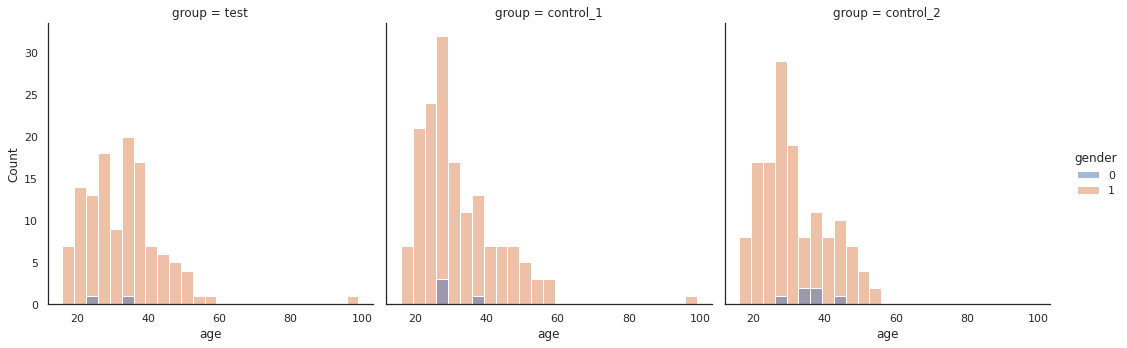

In [332]:
sns.displot(data=users_df, x="age", hue="gender", col="group")
sns.despine()

In [333]:
users_df.groupby('group').age.describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
control_1,162.0,31.783951,11.024377,16.0,25.0,29.0,37.0,99.0
control_2,146.0,31.472603,9.326414,16.0,24.0,30.0,38.0,55.0
test,125.0,32.808000,10.813444,17.0,25.0,33.0,37.0,99.0


Исходя из данных, значительная часть пользователей приложения мужского пола. Средний возраст около 32 лет.  
Проведём тест на гомоскедастичность.  
***Н<sub>0</sub>***: дисперсии между группами равны.  
***Н<sub>1</sub>***: дисперсии между группами различны.

In [334]:
pg.homoscedasticity(users_df, dv="age", group="group")

,W,pval,equal_var
levene,0.112492,0.89363,True


p-value > 0.05, дисперсии в группах статистически не отличаются.  

Также проверим нормальность распределения по тесту Шапиро.  
***Н<sub>0</sub>***: ГС, из которой взята эта выборка, распределена нормально.  
***Н<sub>1</sub>***: ГС, из которой взята эта выборка, распределена не нормально.

In [335]:
pg.normality(users_df, dv="age", group="group", method="shapiro")

,W,pval,normal
group,,,
test,0.864242,2.492877e-09,False
control_1,0.854433,2.185551e-11,False
control_2,0.951260,5.303163e-05,False


Несмотря на довольно похожее на нормальное распредление на графике (скошенное однако в левую сторону), тест говорит о ненормальности распределения, но большой объём выборки и малое количество выбросов позволяют не делать на это поправку.

С помощью дисперсионного анализа сравним среднее между группами.  
***Н<sub>0</sub>***: средние всех анализируемых ГС не различаются.  
***Н<sub>1</sub>***: хотя бы одна пара средних ГС различается.

In [336]:
pg.anova(data=users_df, dv="age", between="group")

,Source,ddof1,ddof2,F,p-unc,np2
0,group,2,430,0.596464,0.551211,0.002767


p-value > 0.05, средний возраст между группами статистически не отличается.

Посмотрим также информацию по самым возрастным пользователям.

In [337]:
users_df.query('age > 80')

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue,group
2642,892065108,99,475,72.0,France,"1,2,3,4,5,6,7,8,9,10,11,12,13,14,16,17,18,19,2...",1,16,41,187,1.0,1.0,47242,test
6411,892185039,99,759,0.0,United Kingdom (Great Britain),"1,2,3,4,5,6,7,8,9",1,43,49,79,1.0,1.0,7332,control_1


В целом, данные пользователи довольно активны в приложении, ранее имели и имеют сейчас статус премиум, а также приносят выручку. Принято решение не удалять их из выборки.

Касаемо пола, проведём ту же аналитику.

In [338]:
users_df.groupby('gender').age.describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
0,12.0,32.666667,5.989890,23.0,27.75,34.5,36.25,43.0
1,421.0,31.954869,10.511688,16.0,24.00,30.0,38.00,99.0


В выборке всего лишь 12 пользователей женского пола, что может насторожить. Необходимо проверить репрезентативность таких данных.  
Проведём тест на гомоскедастичность.  
***Н<sub>0</sub>***: дисперсии между группами равны.  
***Н<sub>1</sub>***: дисперсии между группами различны.

In [339]:
pg.homoscedasticity(users_df, dv="gender", group="group")

,W,pval,equal_var
levene,0.828305,0.437485,True


p-value > 0.05, дисперсии в группах статистически не отличаются.  
Тест Шапиро на нормальность распределения не имеет смысла проводить в силу маленького количества наблюдений. Но в данном случае есть 2 категориальные переменные, используем критерий хи-квадрат, чтобы проверить, зависит ли пол пользователя от группы.  
***Н<sub>0</sub>***: распределение не зависит от группы.  
***Н<sub>1</sub>***: распределение зависит от группы.

In [340]:
gender_group = pd.crosstab(users_df.gender, users_df.group)
stats, p, dof, expected_freq = ss.chi2_contingency(gender_group)
stats, p

(1.661766524609477, 0.4356643104662784)

p-value > 0.05, распределение не зависит от группы.

### Теперь посмотроим график по коэффициенту привлекательности.

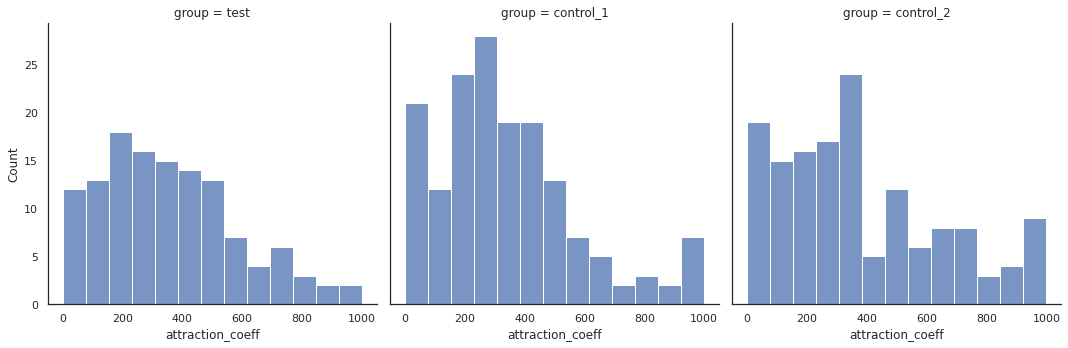

In [341]:
sns.displot(data=users_df, x="attraction_coeff", col="group")
sns.despine()

In [342]:
users_df.groupby('group').attraction_coeff.describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
control_1,162.0,339.067901,243.358849,0.0,186.75,298.0,457.25,1000.0
control_2,146.0,381.726027,277.752148,0.0,189.25,323.5,544.50,1000.0
test,125.0,353.672000,230.166412,0.0,197.00,328.0,487.00,1000.0


Средний коэффициент привлекательности составляет примерно 357 баллов. В контрольной 2 группе встречается наибольшее количество пользователей с самыми высокими оценками привлекательности.

Проведём тест на гомоскедастичность.  
***Н<sub>0</sub>***: дисперсии между группами равны.  
***Н<sub>1</sub>***: дисперсии между группами различны.

In [343]:
pg.homoscedasticity(users_df, dv="attraction_coeff", group="group")

,W,pval,equal_var
levene,2.367825,0.094905,True


p-value > 0.05, дисперсии в группах статистически не отличаются.   
  
Также проверим нормальность распределения по тесту Шапиро.  
***Н<sub>0</sub>***: ГС, из которой взята эта выборка, распределена нормально.  
***Н<sub>1</sub>***: ГС, из которой взята эта выборка, распределена не нормально.

In [344]:
pg.normality(users_df, dv="attraction_coeff", group="group", method="shapiro")

,W,pval,normal
group,,,
test,0.961122,1.182920e-03,False
control_1,0.926290,2.303296e-07,False
control_2,0.935900,3.455178e-06,False


Тест говорит о ненормальности распределения.  
  
С помощью дисперсионного анализа сравним среднее между группами.  
***Н<sub>0</sub>***: средние всех анализируемых ГС не различаются.  
***Н<sub>1</sub>***: хотя бы одна пара средних ГС различается.

In [345]:
pg.anova(data=users_df, dv="attraction_coeff", between="group")

,Source,ddof1,ddof2,F,p-unc,np2
0,group,2,430,1.123009,0.326252,0.005196


p-value > 0.05, средний коэффициент привлекательности между группами статистически не отличается.

### Далее проанализируем информацию по количеству внутренней валюты.

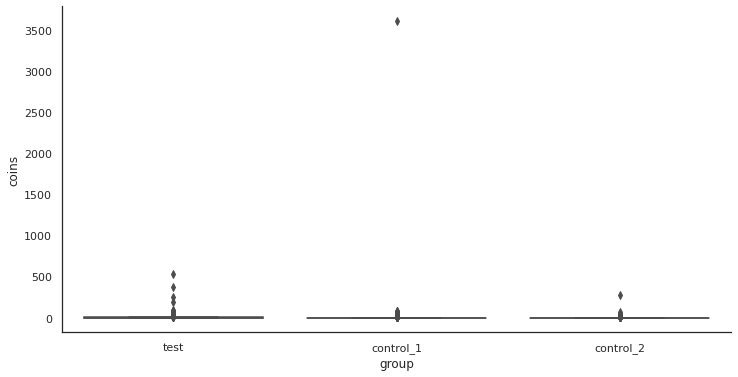

In [346]:
sns.boxplot(data=users_df, x="group", y="coins")
sns.despine()

In [347]:
users_df.groupby('group').coins.describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
control_1,162.0,26.679012,283.394457,0.0,0.0,0.0,0.0,3608.0
control_2,146.0,5.363014,24.122069,0.0,0.0,0.0,0.0,271.0
test,125.0,16.640000,65.389824,0.0,0.0,0.0,2.0,530.0


Практически все пользователи не имеют внутренную валюту. Заметны явные выбросы во всех группах.  
Выведем пользователей с максимальным количеством койнов.

In [348]:
users_df.query('coins > 500')

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue,group
597,891346269,34,204,530.0,Argentina,"1,2,3,4,5,6,7,9,10",1,16,37,44,1.0,1.0,75647,test
5735,892333905,22,175,3608.0,Italy,"1,2,3,4,5,6,7,15",1,19,25,575,1.0,1.0,486330,control_1


In [349]:
transactions_df.query('uid == [891346269, 892333905]')

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type,group
194,891346269,Argentina,2017-05-11,2017-05-11,12597.0,147.0,autoreply_message,premium_no_trial,test
406,892333905,Italy,2017-10-16,2017-10-16,63037.0,147.0,no_sympathy,premium_no_trial,control_1


Данные пользователи не будут удалены из выборки. Критичным выбросом будет считаться всего один из них - 892333905 с 3608 койнами, что не должно повлиять на общие результаты.

Проведём тест на гомоскедастичность.  
***Н<sub>0</sub>***: дисперсии между группами равны.  
***Н<sub>1</sub>***: дисперсии между группами различны.

In [350]:
pg.homoscedasticity(users_df, dv="coins", group="group")

,W,pval,equal_var
levene,0.553856,0.575139,True


p-value > 0.05, дисперсии в группах статистически не отличаются.   
  
Также проверим нормальность распределения по тесту Шапиро.  
***Н<sub>0</sub>***: ГС, из которой взята эта выборка, распределена нормально.  
***Н<sub>1</sub>***: ГС, из которой взята эта выборка, распределена не нормально.

In [351]:
pg.normality(users_df, dv="coins", group="group", method="shapiro")

,W,pval,normal
group,,,
test,0.275077,3.664001e-22,False
control_1,0.064488,1.301534e-27,False
control_2,0.211586,1.246408e-24,False


Тест говорит о ненормальности распределения, что очевидно по графику.

Что касается дисперсионного анализа, вместо него будет использоваться критерий Краскела–Уоллиса, так как в выборке есть экстремальные выбросы и он не требует нормального распределения данных.  
***Н<sub>0</sub>***: распределения всех анализируемых ГС не различаются.  
***Н<sub>1</sub>***: хотя бы одна пара распределений ГС различается.

In [352]:
pg.kruskal(data=users_df, dv="coins", between="group")

,Source,ddof1,H,p-unc
Kruskal,group,2,1.041847,0.593972


p-value > 0.05, распределения между группами не различаются.

### Следующим этапом проанализируем информацию по странам.

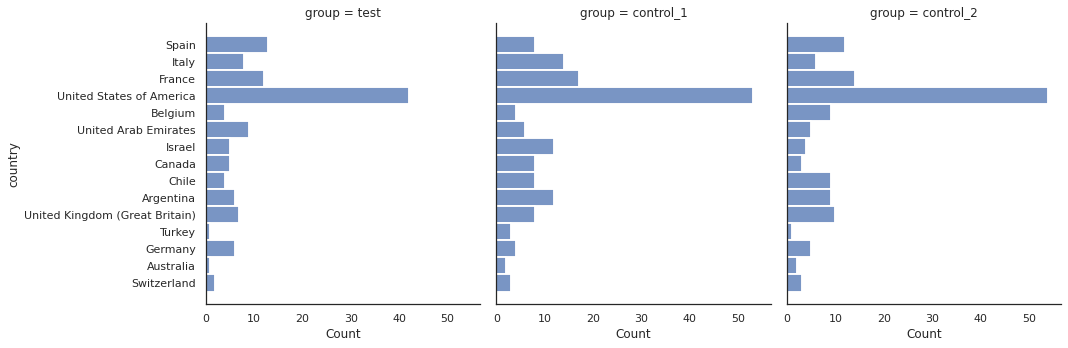

In [353]:
sns.displot(data=users_df, y="country", col="group")
sns.despine()

Больше всего пользователей из США. В остальных странах примерно одинаковое количество юзеров.  
В данном случае имеются 2 категориальные переменные, поэтому составим таблицу сопряжённости и проверим с помощью критерия хи-квадрат, зависит ли страна пользователя от группы.  
***Н<sub>0</sub>***: распределение не зависит от группы.  
***Н<sub>1</sub>***: распределение зависит от группы.

In [354]:
country_group = pd.crosstab(users_df.country, users_df.group)
stats, p, dof, expected_freq = ss.chi2_contingency(country_group)
stats, p

(21.740858495467037, 0.7931449329707946)

p-value > 0.05, распределение не зависит от группы.

### В завершение данного этапа проанализируем информацию по количеству дней, в которые пользователь посещал приложение после регистрации.

In [355]:
#Создаём колонку, которая подсчитывает количество дней посещения
users_df['count_days'] = users_df.visit_days.apply(lambda x: len(str(x).split(',')))

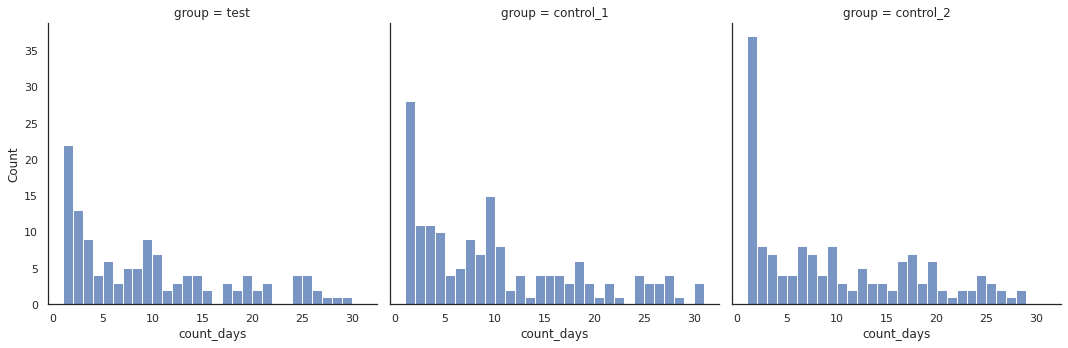

In [356]:
sns.displot(data=users_df, x="count_days", col="group", bins=30)
sns.despine()

In [357]:
users_df.groupby('group').count_days.describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
control_1,162.0,9.685185,8.229980,1.0,3.00,8.0,15.0,31.0
control_2,146.0,9.410959,8.093992,1.0,1.25,7.0,16.0,28.0
test,125.0,9.272000,7.982214,1.0,2.00,8.0,14.0,29.0


Среди пользователей, дата регистрации которых приходится на даты с 11 января 2017 по 31 октября 2017, среднее количество дней, в которые они посещали приложение после регистрации, составляет 9. Реже всего в приложение заходили пользователи из 2 контрольной группы.

Проведём тест на гомоскедастичность.  
***Н<sub>0</sub>***: дисперсии между группами равны.  
***Н<sub>1</sub>***: дисперсии между группами различны.

In [358]:
pg.homoscedasticity(users_df, dv="count_days", group="group")

,W,pval,equal_var
levene,0.187264,0.829293,True


p-value > 0.05, дисперсии в группах статистически не отличаются.  
  
Также проверим нормальность распределения по тесту Шапиро.  
***Н<sub>0</sub>***: ГС, из которой взята эта выборка, распределена нормально.  
***Н<sub>1</sub>***: ГС, из которой взята эта выборка, распределена не нормально.

In [359]:
pg.normality(users_df, dv="count_days", group="group", method="shapiro")

,W,pval,normal
group,,,
test,0.879596,1.215404e-08,False
control_1,0.885088,7.122367e-10,False
control_2,0.883711,2.534947e-09,False


Тест говорит о ненормальности распределения.  
  
С помощью дисперсионного анализа сравним среднее между группами.  
***Н<sub>0</sub>***: средние всех анализируемых ГС не различаются.  
***Н<sub>1</sub>***: хотя бы одна пара средних ГС различается.

In [360]:
pg.anova(data=users_df, dv="count_days", between="group")

,Source,ddof1,ddof2,F,p-unc,np2
0,group,2,430,0.098029,0.906643,0.000456


p-value > 0.05, среднее количество дней посещения приложения между группами статистически не отличаются.

### Итак, предварительный анализ показал, что наши данные в 3 группах репрезентативны. На основании этого факта принято решение объединить контрольные группы в одну. К тому же, выборка станет больше, следовательно, повысится чувствительность к изменениям и уменьшится MDE.

In [361]:
users_df['group'] = users_df['group'].replace({'control_1': 'control', 'control_2': 'control'})
transactions_df['group'] = transactions_df['group'].replace({'control_1': 'control', 'control_2': 'control'})

## 3. Анализ результатов A/B теста. Расчёт метрик и проверка гипотез.

Чтобы проверить, был ли эксперимент по изменению стоимости премиум-подписки успешен, в данном проекте будут рассчитаны и проанализированы следующие метрики:  
- **ARPPU** - выручка на платящего пользователя, поскольку в итоговой выборке все пользователи приобретали продукт(подписку);  
- **Churn Rate** - какая доля прошлой активной базы не вернулась, то есть доля пользователей, которая приобрела подписку, но отменила продление  
  
При сравнении **ARPPU** между группами гипотеза звучит следующим образом:  
***Н<sub>0</sub>***: средняя выручка тестовой и контрольной групп не различаются.  
***Н<sub>1</sub>***: средняя выручка тестовой и контрольной групп различаются.  
  
Для начала рассчитаем метрику для каждой группы (только с наличием премиума и без пробной подписки).

In [362]:
test_users_premium = list(transactions_df.query('product_type == "premium_no_trial" and group == "test"').uid)
test_users_premium_was_premium = users_df[users_df['uid'].isin(test_users_premium)]
test_users_premium_was_premium = test_users_premium_was_premium.query('was_premium == 1')


control_users_premium = list(transactions_df.query('product_type == "premium_no_trial" and group == "control"').uid)
control_users_premium_was_premium = users_df[users_df['uid'].isin(control_users_premium)]
control_users_premium_was_premium = control_users_premium_was_premium.query('was_premium == 1')

ARPPU_df = pd.concat([test_users_premium_was_premium, control_users_premium_was_premium], ignore_index=True)

In [363]:
ARPPU_test = test_users_premium_was_premium.total_revenue.sum() / len(test_users_premium_was_premium.uid)
ARPPU_control = control_users_premium_was_premium.total_revenue.sum()/ len(control_users_premium_was_premium.uid)
round(pd.DataFrame({'ARPPU_test' : [ARPPU_test], 
             'ARPPU_control' : [ARPPU_control]}),2)

,ARPPU_test,ARPPU_control
0,18255.2,13162.33


Ручной расчёт показывает, что среди пользователей, которые приобрели премиум и на момент эксперимента являются премиум-пользователями, большую выручку приносит тестовая группа.  
Проведём тест на гомоскедастичность.  
***Н<sub>0</sub>***: дисперсии между группами равны.  
***Н<sub>1</sub>***: дисперсии между группами различны.

In [364]:
pg.homoscedasticity(ARPPU_df, dv="total_revenue", group="group")

,W,pval,equal_var
levene,0.446161,0.50477,True


p-value > 0.05, дисперсии в группах статистически не отличаются.  
Также проверим нормальность распределения по тесту Шапиро.  
***Н<sub>0</sub>***: ГС, из которой взята эта выборка, распределена нормально.  
***Н<sub>1</sub>***: ГС, из которой взята эта выборка, распределена не нормально.

In [365]:
pg.normality(ARPPU_df, dv="total_revenue", group="group", method="shapiro")

,W,pval,normal
group,,,
test,0.529580,4.079757e-13,False
control,0.186318,4.418368e-28,False


Тест говорит о ненормальности распределения.  
Проведём Т-тест, чтобы удостовериться, статистически значимо ли различие в средних.

In [366]:
pg.ttest(test_users_premium_was_premium.total_revenue, control_users_premium_was_premium.total_revenue)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,1.258578,163.140563,two-sided,0.209981,"[-2897.45, 13083.19]",0.150411,0.327,0.181044


p-value > 0.05, мы принимаем нулевую гипотезу, значит, средняя выручка тестовой и контрольной групп статистически не различаются.

### Помимо сравнения средней выручки между группами, мы можем проанализировать, какие переменные влияют на нормированную выручку. Для этого построим **множественную линейную регрессию**.  
Первым этапом отберём возможные независимые переменные и проверим наличие корреляции между ними.  
- 0.1 - 0.3: слабая корреляция
- 0.3 - 0.5: средняя корреляция
- 0.5 и выше: сильная корреляция  

При наличии корреляции в 0.5 и выше, переменные не будут добавлены в анализ.

In [367]:
ARPPU_df_corr = ARPPU_df[['age', 'attraction_coeff', 'coins', 'views_count', 'count_days']].corr()
ARPPU_df_corr

,age,attraction_coeff,coins,views_count,count_days
age,1.000000,0.035473,-0.037402,0.030048,0.053538
attraction_coeff,0.035473,1.000000,-0.066688,-0.120637,-0.130245
coins,-0.037402,-0.066688,1.000000,0.028993,-0.001478
views_count,0.030048,-0.120637,0.028993,1.000000,0.011039
count_days,0.053538,-0.130245,-0.001478,0.011039,1.000000


In [368]:
pg.pairwise_corr(data=ARPPU_df_corr)

,X,Y,method,alternative,n,r,CI95%,p-unc,BF10,power
0,age,attraction_coeff,pearson,two-sided,5,-0.108850,"[-0.9, 0.86]",0.861682,0.541,0.056546
1,age,coins,pearson,two-sided,5,-0.343608,"[-0.94, 0.77]",0.571273,0.615,0.091820
2,age,views_count,pearson,two-sided,5,-0.186737,"[-0.92, 0.83]",0.763629,0.555,0.063710
3,age,count_days,pearson,two-sided,5,-0.122428,"[-0.91, 0.85]",0.844510,0.543,0.057509
4,attraction_coeff,coins,pearson,two-sided,5,-0.306175,"[-0.94, 0.79]",0.616345,0.596,0.083222
5,attraction_coeff,views_count,pearson,two-sided,5,-0.429860,"[-0.95, 0.73]",0.470042,0.671,0.117193
6,attraction_coeff,count_days,pearson,two-sided,5,-0.442961,"[-0.95, 0.72]",0.455034,0.682,0.121826
7,coins,views_count,pearson,two-sided,5,-0.132103,"[-0.91, 0.85]",0.832292,0.544,0.058267
8,coins,count_days,pearson,two-sided,5,-0.200041,"[-0.92, 0.83]",0.747009,0.559,0.065346
9,views_count,count_days,pearson,two-sided,5,-0.163830,"[-0.91, 0.84]",0.792342,0.55,0.061183


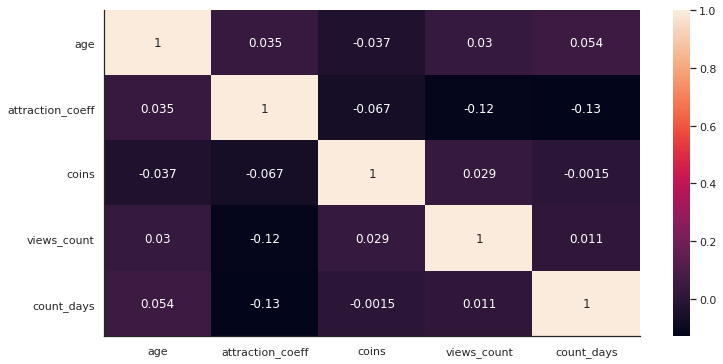

In [369]:
sns.heatmap(data=ARPPU_df_corr, annot=True)
sns.despine()

Исходя из результатов анализа корреляции, независимы переменные слабо и статистически не значимо коррелируют между собой.

### Начинаем строить регрессию.

In [370]:
#ЗП
y = ARPPU_df["total_revenue"] 

#НП
X = ARPPU_df[['age', 'attraction_coeff', 'coins', 'views_count', 'count_days', 'group']]

In [371]:
#Задаём свободный член

X = sm.add_constant(X)

In [372]:
X = pd.get_dummies(X, 
                   drop_first=True) #преобразуем категориальную переменную
X

,const,age,attraction_coeff,coins,views_count,count_days,group_test
0,1.0,29,769,0.0,13,3,1
1,1.0,21,303,37.0,181,9,1
2,1.0,32,57,0.0,69,18,1
3,1.0,36,408,76.0,71,18,1
4,1.0,33,0,0.0,4,1,1
...,...,...,...,...,...,...,...
251,1.0,20,248,0.0,181,6,0
252,1.0,36,43,0.0,1317,19,0
253,1.0,23,548,0.0,31,17,0
254,1.0,30,250,0.0,8,16,0


In [373]:
#Выводим регрессионную модель
model_revenue = sm.OLS(endog=y, exog=X).fit(cov_type="HC3")
model_revenue.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          total_revenue   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     5.944
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           8.06e-06
Time:                        17:46:23   Log-Likelihood:                -2805.7
No. Observations:                 256   AIC:                             5625.
Df Residuals:                     249   BIC:                             5650.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const             6220.8028   2600.048      2.393      0.017    1124.802    1.13e+04
age                 -6.0098     89.330     -0.067      0.946    -181.094     169.075
attraction_coeff     0.1307      3.221      0.041      0.968      -6.183       6.445
coins              133.5998     31.731      4.210      0.000      71.409     195.791
views_count          0.1252      6.652      0.019      0.985     -12.913      13.164
count_days         338.5206    145.974      2.319      0.020      52.417     624.624
group_test        4990.7048   2720.459      1.835      0.067    -341.298    1.03e+04
==============================================================================
Omnibus:                      288.077   Durbin-Watson:                   2.166
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            10121.584
Skew:                           4.866   Prob(JB):                         0.00
Kurtosis:                      32.226   Cond. No.                     3.90e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 3.9e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Выводы модели:**
- R<sup>2</sup> и R<sup>2</sup> скорректированный примерно равны, значит значение нормированной выручки на 83% объясняется независимыми переменными  
- При увеличении **возраста** пользователя на 1 год нормированная выручка падает на 6 у.е., , <span style="color: red;">но это отличие статистически незначимо.</span>
- При увеличении **коэффициента привлекательности** пользователя на 1 балл нормированная выручка растёт на 0,13 у.е., <span style="color: red;"> но это отличие статистически незначимо. </span> 
- При увеличении **внутриигровой валюты** пользователя на 1 койн нормированная выручка растёт на 133 у.е.  
- Когда пользователь получает 1 **оценку** нормированная выручка растёт на 0,12 у.е., <span style="color: red;">но это отличие статистически незначимо.</span>
- При увеличении **количества дней посещения** приложения на 1 нормированная выручка растёт на 338 у.е.  
- Средняя нормированная выручка пользователей из тестовой группы выше на 4990 у.е, чем в контрольной, <span style="color: red;">но это отличие статистически незначимо</span>, что соответствует результатам Т-теста.  

  
- Тест Omnibus (Д'Агостино-Пирсона) говорит о ненормальности распределения.  
- Тест Durbin-Watson говорит о независимости наблюдений, возникающей при анализе меняющихся во времени данных.  
- Cond. No. сообщает о возможной мультиколлинеарности, необходима дополнительная диагностика.

In [374]:
#Проверка на мультиколлинеарность
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns

vif

,VIF,features
0,13.695403,const
1,1.015456,age
2,1.039274,attraction_coeff
3,1.006279,coins
4,1.018733,views_count
5,1.023114,count_days
6,1.013415,group_test


Проблематика не наблюдается.

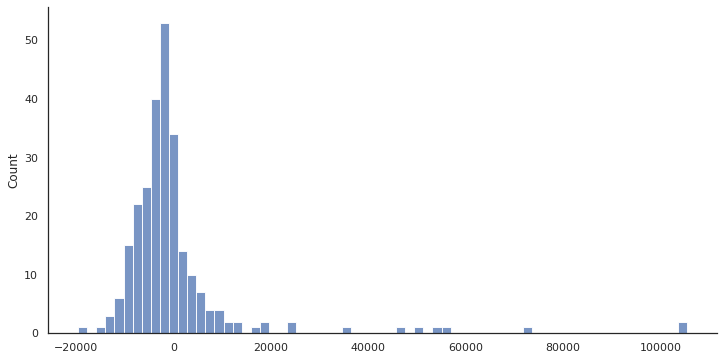

In [375]:
#Нормальность остатков
sns.histplot(model_revenue.resid)
sns.despine()

Визуально распределение похоже на нормальное, это хорошо.

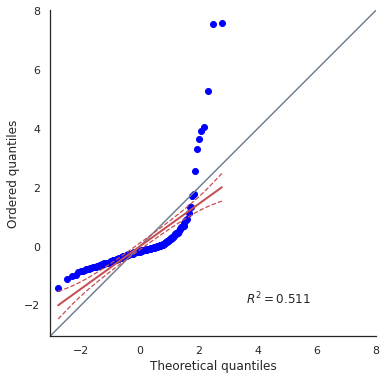

In [376]:
#QQ-график
pg.qqplot(model_revenue.resid)
sns.despine()

По QQ графику наблюдаются "рога", ориентированные вверх - признак правосторонней асимметрии. Это означает, что примерно посередине квантили более-менее совпадают, но по обоим краям "реальные" квантили оказываются выше теоретических.

### Далее рассчитаем метрику Churn Rate - какая доля прошлой активной базы не вернулась, в контексте текущей задачи это доля пользователей, которая приобрела подписку, но отменила продление.  
Создадим колонку с категориальной переменной "status": cancelled - пользователь отменил подписку, not_cancelled - не отменил.

In [377]:
users_df['status'] = users_df.is_premium.apply(lambda x: 'not_cancelled' if x == 1 else 'cancelled')

In [378]:
status_premium_df = users_df.groupby(['group', 'status']).agg({'uid' : 'count'}).reset_index()
total_per_group = status_premium_df.groupby('group')['uid'].transform('sum')
status_premium_df['percent'] = round(status_premium_df['uid'] / total_per_group *100, 2)
status_premium_df[['group', 'status', 'percent']]

,group,status,percent
0,control,cancelled,7.47
1,control,not_cancelled,92.53
2,test,cancelled,5.60
3,test,not_cancelled,94.40


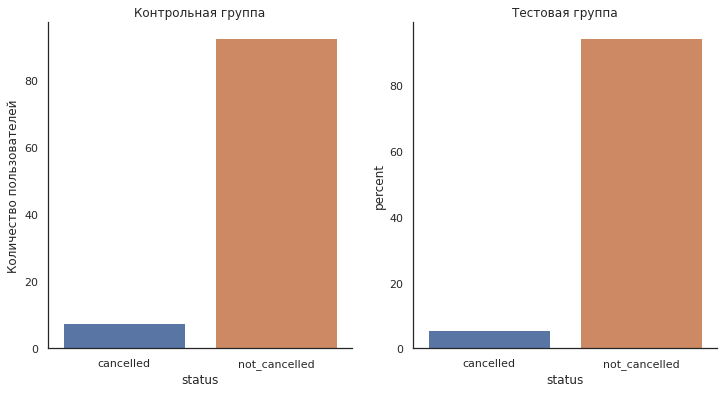

In [379]:
fig, (ax1, ax2) = plt.subplots(1, 2)

# График для контрольной группы
control_data = status_premium_df.query('group == "control"')
sns.barplot(data=control_data, x='status', y='percent', ax=ax1)
ax1.set_title('Контрольная группа')
ax1.set_ylabel('Количество пользователей')

# График для тестовой группы
test_data = status_premium_df.query('group == "test"')
sns.barplot(data=test_data, x='status', y='percent', ax=ax2)
ax2.set_title('Тестовая группа')
sns.despine()

В обоих группах значительная часть пользователей не отменяла продление подписки, и **Churn Rate** для тестовой группы составляет 6%, для контрольной - 7%.

Имеются 2 категориальные переменные, поэтому составим таблицу сопряжённости и проверим с помощью критерия хи-квадрат, зависит ли статус (не)продления пользователя от группы.  
***Н<sub>0</sub>***: распределение не зависит от группы.  
***Н<sub>1</sub>***: распределение зависит от группы.

In [380]:
status_premium = pd.crosstab(users_df.status, users_df.group)
stats, p, dof, expected_freq = ss.chi2_contingency(status_premium)
stats, p

(0.2348945812252266, 0.6279180824738537)

p-value > 0.05, распределение не зависит от группы.

## 4. Выводы и предложения. 

Итак, после проведённой аналитики мы можем сделать выводы об эксперименте по изменению цены платной подписки в дейтинг-приложении.  
**ARPPU**: метрика, отображающая среднюю выручку на платящего пользователя, статистически не изменилась. То есть средняя выручка между тестовой и контрольной группой, несмотря на увеличение в тестовой группе на 5 тыс. у.е. в абсолютных величинах, глобально не повлияла на продукт.  
**Churn Rate**: доля пользователей, отменивших подписку, скоратилась на 2% в тестовой группе по сравнению с контрольной.  
Так, мы наблюдаем интересную закономерность: стало меньше отмен подписки, но при этом выручка значимо не изменилась. Мы можем предположить, что причиной тому стали новые платёжные системы и цена самой подписки (по условию эксперимента мы не знаем, в какую сторону поменялась цена). Скорее всего, цена стала меньше, следовательно, большая доля пользователей стала покупать подписки, а также платёжные системы улучшили пользовательский опыт, и процесс оплаты теперь более прост и понятен юзеру.  

К тому же, регрессионная модель показала, что количество дней посещения влияет на нормированную выручку. Можно предположить, что более "преданные" и активные пользователи приложения с большей вероятностью покупают подписку. Также на выручку влияет количество монет пользователей. То есть данная группа юзеров пользуется всеми донатными преимуществами приложения. Необходимо сфокусироваться на удержании этой группы людей.